# Trực quan hóa dữ liệu - bản đã chuẩn hóa

Notebook này đọc trực tiếp `processed/processed_data.csv` do notebook tiền xử lý tạo ra.  
Các lỗi đã được chỉnh:
- Không dùng lại cột `gdp_per_capita` đã bị thay bằng `log1p_gdp_per_capita`.
- Không log thêm một lần nữa trên biến GDP đã log.
- Loại bỏ cell tính lặp lại và gom các biểu đồ theo nhóm rõ ràng.


## 1. Chuẩn bị môi trường và đường dẫn

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.options.display.float_format = lambda x: f"{x:,.4f}"


In [2]:
ROOT = Path.cwd()

DATA_PATH_CANDIDATES = [
    ROOT / "processed" / "processed_data.csv",
    ROOT / "processed_data.csv",
    ROOT.parent / "data" / "processed" / "processed_data.csv",
    Path("/mnt/data/processed/processed_data.csv"),
]

DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy processed_data.csv. Hãy chạy notebook data_preprocessing_cleaned.ipynb trước."
    )

PLOT_DIR = DATA_PATH.parent / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("PLOT_DIR:", PLOT_DIR)


DATA_PATH: c:\Users\Xuanuio\Desktop\Deadline\Kho_DL\Data_Minning\Minning\Data\processed\processed_data.csv
PLOT_DIR: c:\Users\Xuanuio\Desktop\Deadline\Kho_DL\Data_Minning\Minning\Data\processed\plots


## 2. Đọc dữ liệu đã xử lý

In [3]:
df = pd.read_csv(DATA_PATH)

df["year"] = df["year"].astype(int)

# Khôi phục GDP gốc chỉ để vẽ biểu đồ xu hướng tiền tệ.
# Tập mô hình vẫn dùng log1p_gdp_per_capita.
if "log1p_gdp_per_capita" in df.columns:
    df["gdp_per_capita_reconstructed"] = np.expm1(df["log1p_gdp_per_capita"])

print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")
print(f"Khoảng năm: {df['year'].min()} - {df['year'].max()}")
print(f"Số quốc gia/vùng lãnh thổ: {df['country_name'].nunique()}")
df.head()


Số dòng: 5642
Số cột: 18
Khoảng năm: 2000 - 2025
Số quốc gia/vùng lãnh thổ: 217


,country_name,country_code,year,population,pop_growth,life_expectancy,gdp_growth,sanitation,electricity,water_access,co2_emissions,labor_force,is_covid,log1p_gdp_per_capita,electricity_water_interaction,basic_services_gap,split,gdp_per_capita_reconstructed
0,Afghanistan,AFG,2000,"20,130,327.0000",1.2122,55.0050,3.4661,10.1321,4.4000,29.7310,0.0501,46.5710,0,5.1701,1.3082,85.2456,train,174.9310
1,Afghanistan,AFG,2001,"20,284,307.0000",0.7620,55.5110,-9.4320,10.1315,9.3000,29.7629,0.0464,46.5330,0,4.9395,2.7680,83.6019,train,138.7068
2,Afghanistan,AFG,2002,"21,378,117.0000",5.2520,56.2250,28.6000,10.8540,14.1000,31.8361,0.0439,46.5080,0,5.1927,4.4889,81.0700,train,178.9541
3,Afghanistan,AFG,2003,"22,733,049.0000",6.1452,57.1710,8.8323,11.5763,19.0000,33.9086,0.0447,46.4990,0,5.2977,6.4426,78.5050,train,198.8711
4,Afghanistan,AFG,2004,"23,560,654.0000",3.5758,57.8100,1.4141,12.2981,23.8000,35.9994,0.0383,46.5070,0,5.4061,8.5678,75.9675,train,221.7637


In [4]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing": [int(df[c].isna().sum()) for c in df.columns],
    "missing_percent": [df[c].isna().mean() * 100 for c in df.columns],
})

summary


,column,dtype,missing,missing_percent
0,country_name,object,0,0.0000
1,country_code,object,0,0.0000
2,year,int64,0,0.0000
3,population,float64,0,0.0000
4,pop_growth,float64,0,0.0000
5,life_expectancy,float64,0,0.0000
6,gdp_growth,float64,0,0.0000
7,sanitation,float64,0,0.0000
8,electricity,float64,0,0.0000
9,water_access,float64,0,0.0000


## 3. Tương quan giữa các biến chính

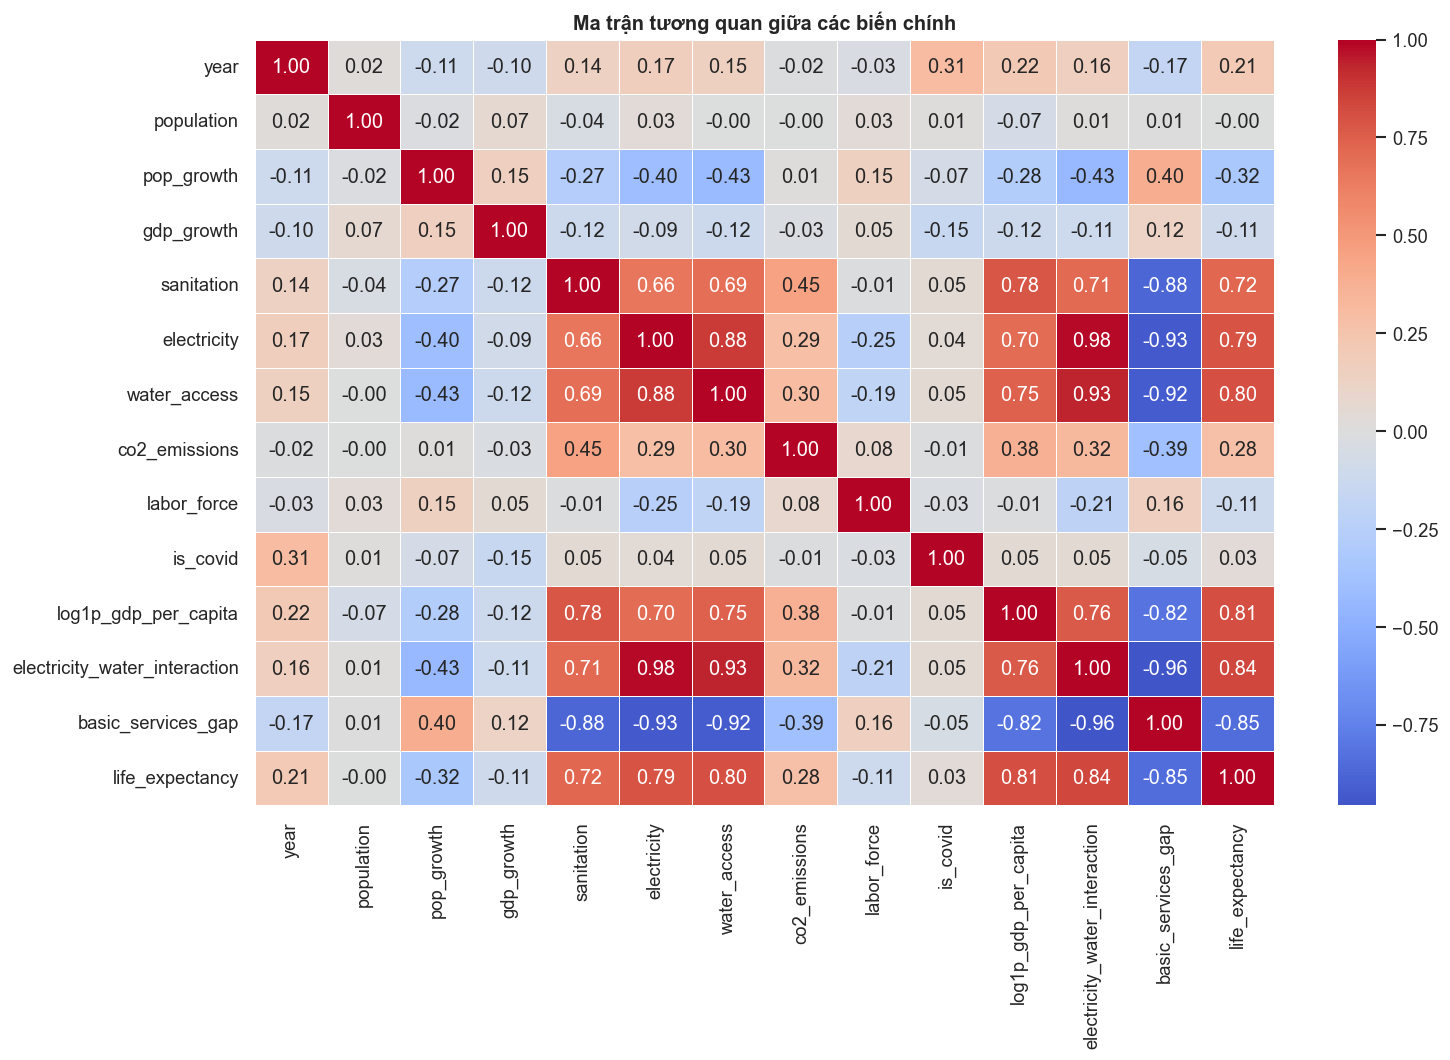

In [5]:
corr_cols = [
    "year",
    "population",
    "pop_growth",
    "gdp_growth",
    "sanitation",
    "electricity",
    "water_access",
    "co2_emissions",
    "labor_force",
    "is_covid",
    "log1p_gdp_per_capita",
    "electricity_water_interaction",
    "basic_services_gap",
    "life_expectancy",
]

corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(13, 9))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Ma trận tương quan giữa các biến chính", fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()


## 4. Phân phối các biến quan trọng

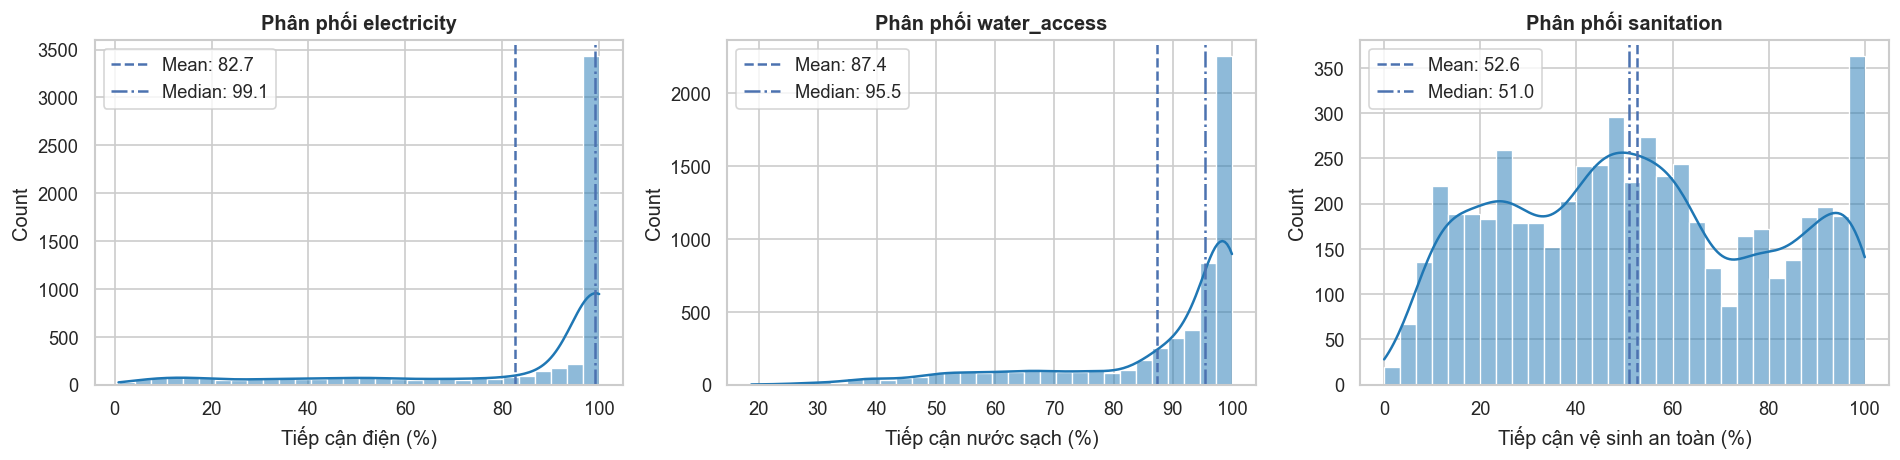

In [6]:
service_cols = ["electricity", "water_access", "sanitation"]
service_labels = {
    "electricity": "Tiếp cận điện (%)",
    "water_access": "Tiếp cận nước sạch (%)",
    "sanitation": "Tiếp cận vệ sinh an toàn (%)",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, service_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#1f77b4")
    ax.axvline(df[col].mean(), linestyle="--", label=f"Mean: {df[col].mean():.1f}")
    ax.axvline(df[col].median(), linestyle="-.", label=f"Median: {df[col].median():.1f}")
    ax.set_title(f"Phân phối {col}", fontweight="bold")
    ax.set_xlabel(service_labels[col])
    ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / "service_distribution.png", bbox_inches="tight")
plt.show()


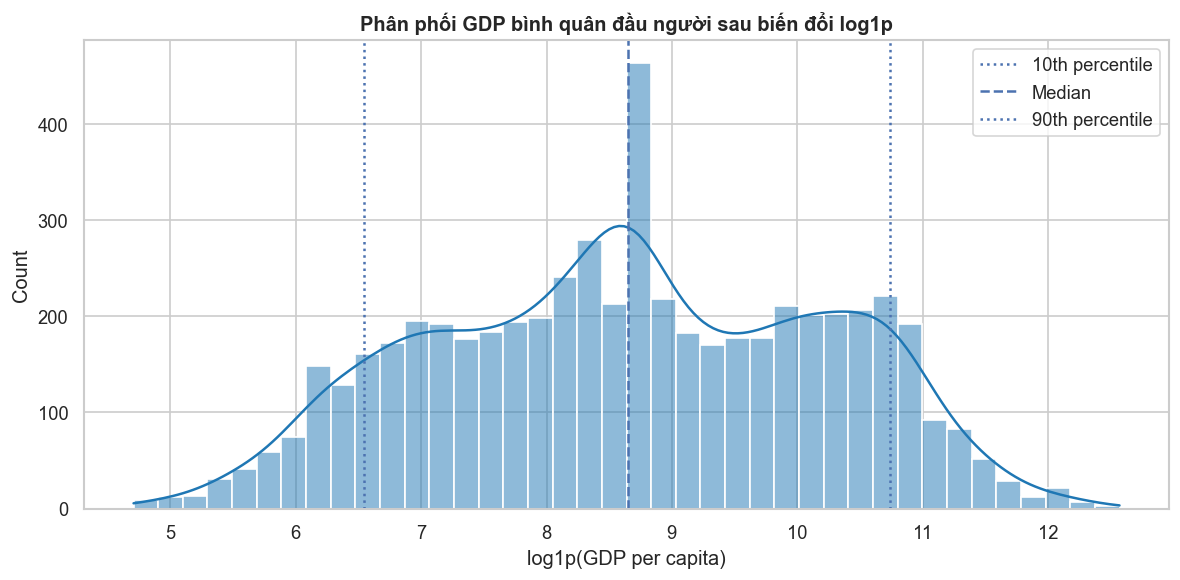

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

gdp_q10, gdp_q50, gdp_q90 = df["log1p_gdp_per_capita"].quantile([0.10, 0.50, 0.90])

sns.histplot(df["log1p_gdp_per_capita"], bins=40, kde=True, ax=ax, color="#1f77b4")
ax.axvline(gdp_q10, linestyle=":", label="10th percentile")
ax.axvline(gdp_q50, linestyle="--", label="Median")
ax.axvline(gdp_q90, linestyle=":", label="90th percentile")
ax.set_title("Phân phối GDP bình quân đầu người sau biến đổi log1p", fontweight="bold")
ax.set_xlabel("log1p(GDP per capita)")
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / "log_gdp_distribution.png", bbox_inches="tight")
plt.show()


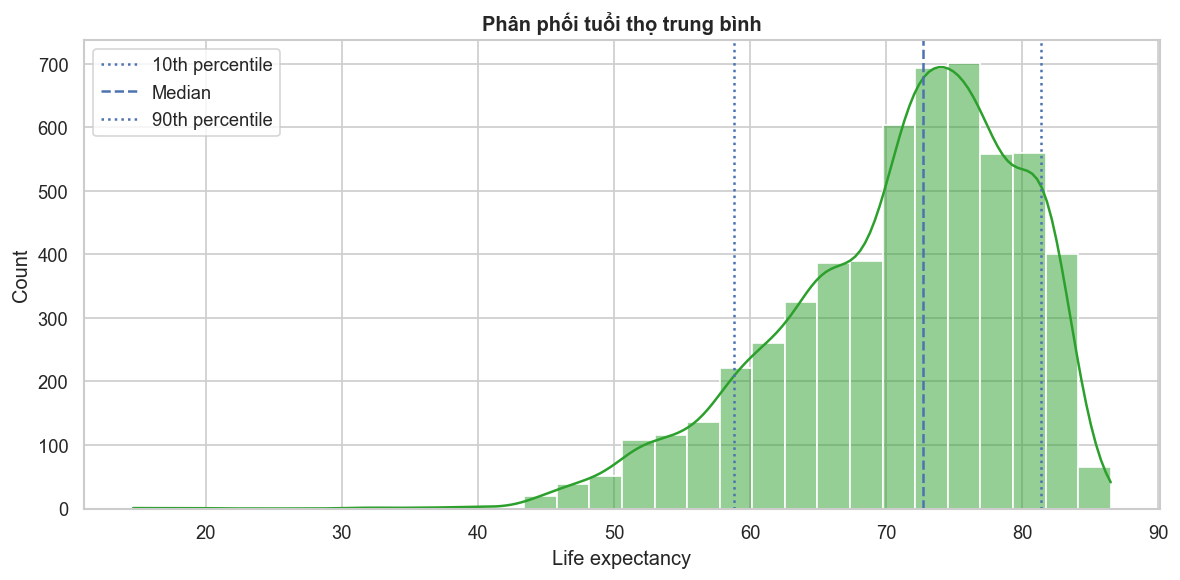

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

life_q10, life_q50, life_q90 = df["life_expectancy"].quantile([0.10, 0.50, 0.90])

sns.histplot(df["life_expectancy"], bins=30, kde=True, ax=ax, color="#2ca02c")
ax.axvline(life_q10, linestyle=":", label="10th percentile")
ax.axvline(life_q50, linestyle="--", label="Median")
ax.axvline(life_q90, linestyle=":", label="90th percentile")
ax.set_title("Phân phối tuổi thọ trung bình", fontweight="bold")
ax.set_xlabel("Life expectancy")
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / "life_expectancy_distribution.png", bbox_inches="tight")
plt.show()


## 5. Quan hệ giữa các biến chính và tuổi thọ

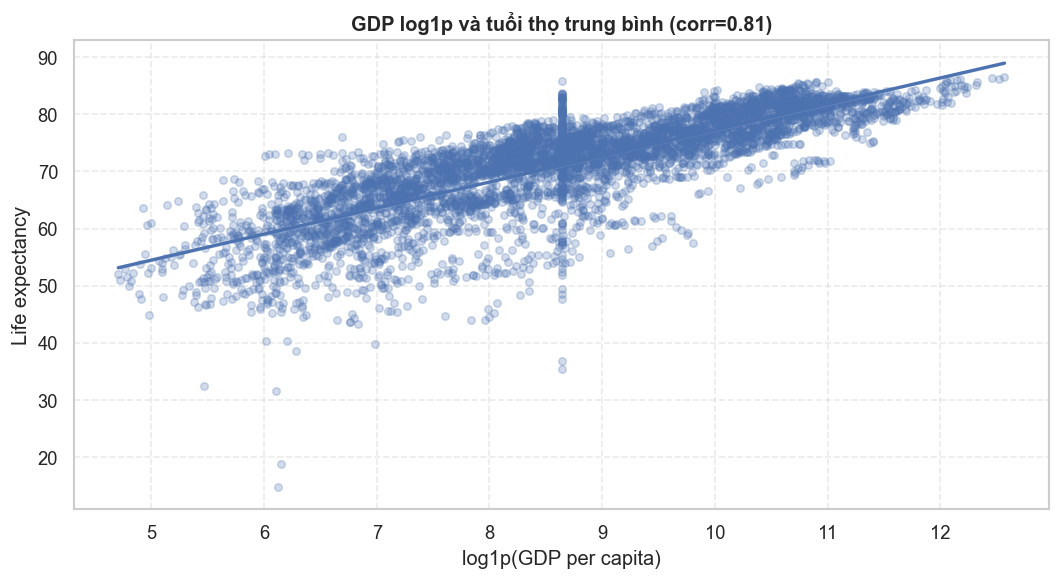

In [9]:
plt.figure(figsize=(9, 5))

sns.regplot(
    data=df,
    x="log1p_gdp_per_capita",
    y="life_expectancy",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"linewidth": 2},
)

corr = df[["log1p_gdp_per_capita", "life_expectancy"]].corr().iloc[0, 1]
plt.title(f"GDP log1p và tuổi thọ trung bình (corr={corr:.2f})", fontweight="bold")
plt.xlabel("log1p(GDP per capita)")
plt.ylabel("Life expectancy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "gdp_vs_life_expectancy.png", bbox_inches="tight")
plt.show()


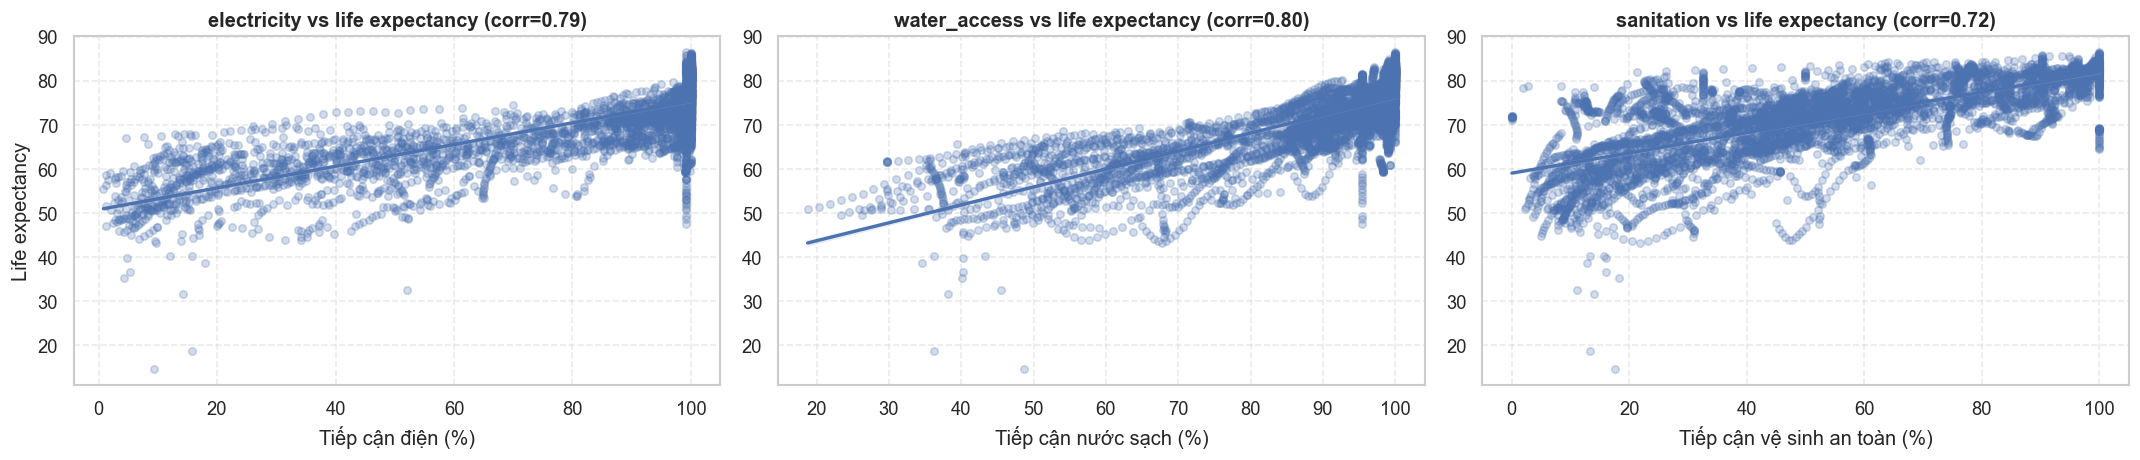

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, service_cols):
    sns.regplot(
        data=df,
        x=col,
        y="life_expectancy",
        scatter_kws={"alpha": 0.25, "s": 20},
        line_kws={"linewidth": 2},
        ax=ax,
    )
    corr = df[[col, "life_expectancy"]].corr().iloc[0, 1]
    ax.set_title(f"{col} vs life expectancy (corr={corr:.2f})", fontweight="bold")
    ax.set_xlabel(service_labels[col])
    ax.set_ylabel("Life expectancy" if col == service_cols[0] else "")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(PLOT_DIR / "services_vs_life_expectancy.png", bbox_inches="tight")
plt.show()


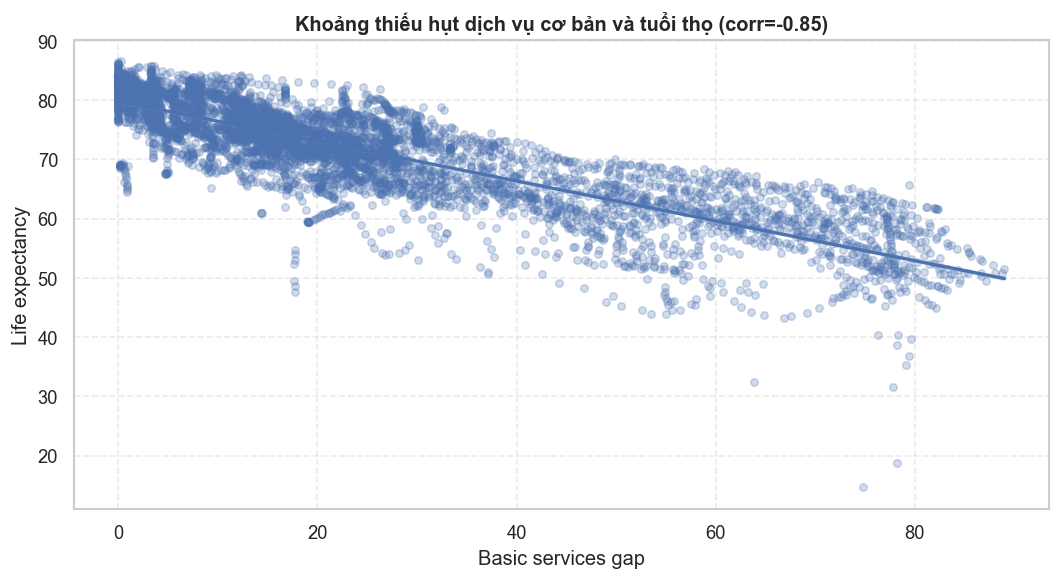

In [11]:
plt.figure(figsize=(9, 5))

sns.regplot(
    data=df,
    x="basic_services_gap",
    y="life_expectancy",
    scatter_kws={"alpha": 0.25, "s": 20},
    line_kws={"linewidth": 2},
)

corr = df[["basic_services_gap", "life_expectancy"]].corr().iloc[0, 1]
plt.title(f"Khoảng thiếu hụt dịch vụ cơ bản và tuổi thọ (corr={corr:.2f})", fontweight="bold")
plt.xlabel("Basic services gap")
plt.ylabel("Life expectancy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "basic_services_gap_vs_life_expectancy.png", bbox_inches="tight")
plt.show()


## 6. Xu hướng toàn cầu theo năm

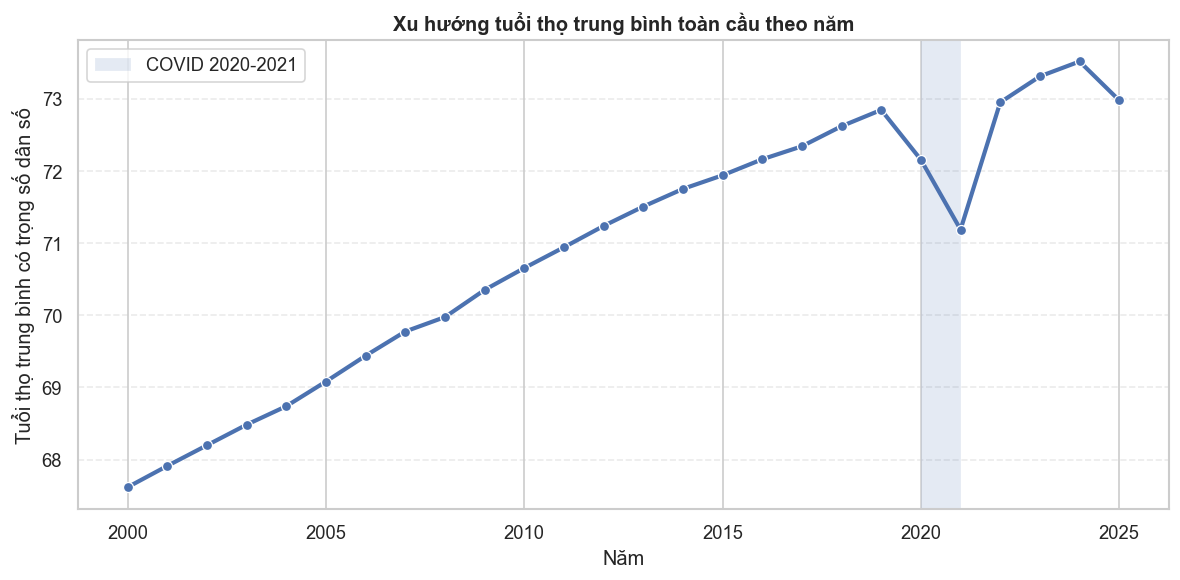

Thay đổi 2020 so với 2019: -0.6899
Thay đổi 2021 so với 2020: -0.9679
Thay đổi 2021 so với 2019: -1.6578


In [12]:
def weighted_mean(data, value_col, weight_col="population"):
    valid = data[[value_col, weight_col]].dropna()
    valid = valid[valid[weight_col] > 0]
    if valid.empty:
        return np.nan
    return np.average(valid[value_col], weights=valid[weight_col])


life_trend = (
    df.groupby("year")
      .apply(lambda g: weighted_mean(g, "life_expectancy"))
      .reset_index(name="weighted_life_expectancy")
      .sort_values("year")
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=life_trend,
    x="year",
    y="weighted_life_expectancy",
    marker="o",
    linewidth=2.5,
)
plt.axvspan(2020, 2021, alpha=0.15, label="COVID 2020-2021")
plt.title("Xu hướng tuổi thọ trung bình toàn cầu theo năm", fontweight="bold")
plt.xlabel("Năm")
plt.ylabel("Tuổi thọ trung bình có trọng số dân số")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "global_life_expectancy_trend.png", bbox_inches="tight")
plt.show()

lookup = life_trend.set_index("year")["weighted_life_expectancy"]
if all(y in lookup.index for y in [2019, 2020, 2021]):
    print("Thay đổi 2020 so với 2019:", round(lookup.loc[2020] - lookup.loc[2019], 4))
    print("Thay đổi 2021 so với 2020:", round(lookup.loc[2021] - lookup.loc[2020], 4))
    print("Thay đổi 2021 so với 2019:", round(lookup.loc[2021] - lookup.loc[2019], 4))


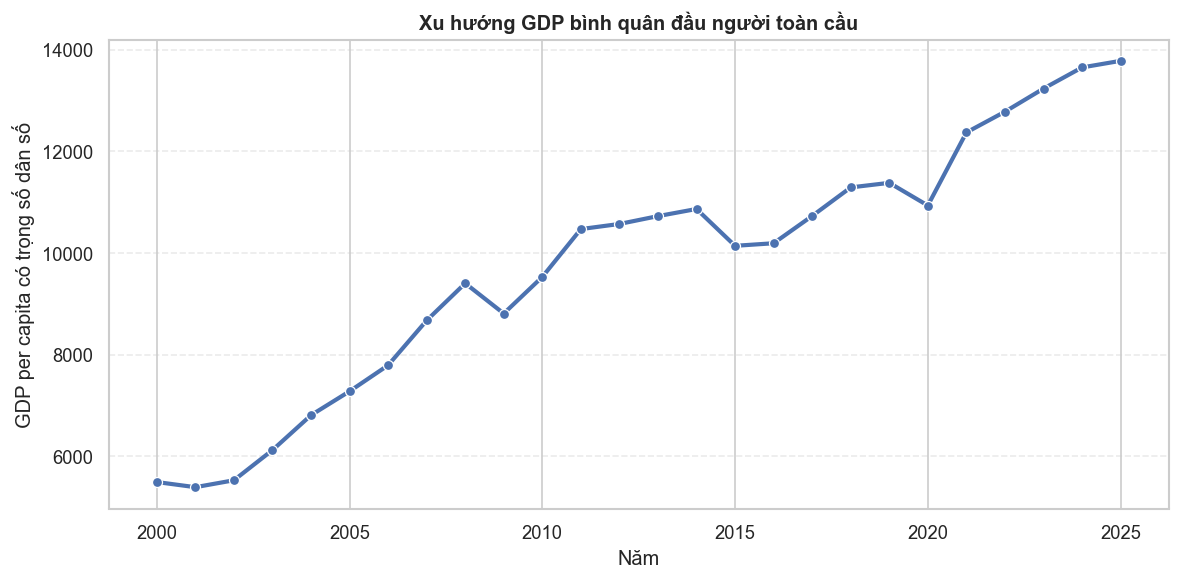

In [13]:
gdp_trend = (
    df.groupby("year")
      .apply(lambda g: weighted_mean(g, "gdp_per_capita_reconstructed"))
      .reset_index(name="weighted_gdp_per_capita")
      .sort_values("year")
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=gdp_trend,
    x="year",
    y="weighted_gdp_per_capita",
    marker="o",
    linewidth=2.5,
)
plt.title("Xu hướng GDP bình quân đầu người toàn cầu", fontweight="bold")
plt.xlabel("Năm")
plt.ylabel("GDP per capita có trọng số dân số")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "global_gdp_trend.png", bbox_inches="tight")
plt.show()


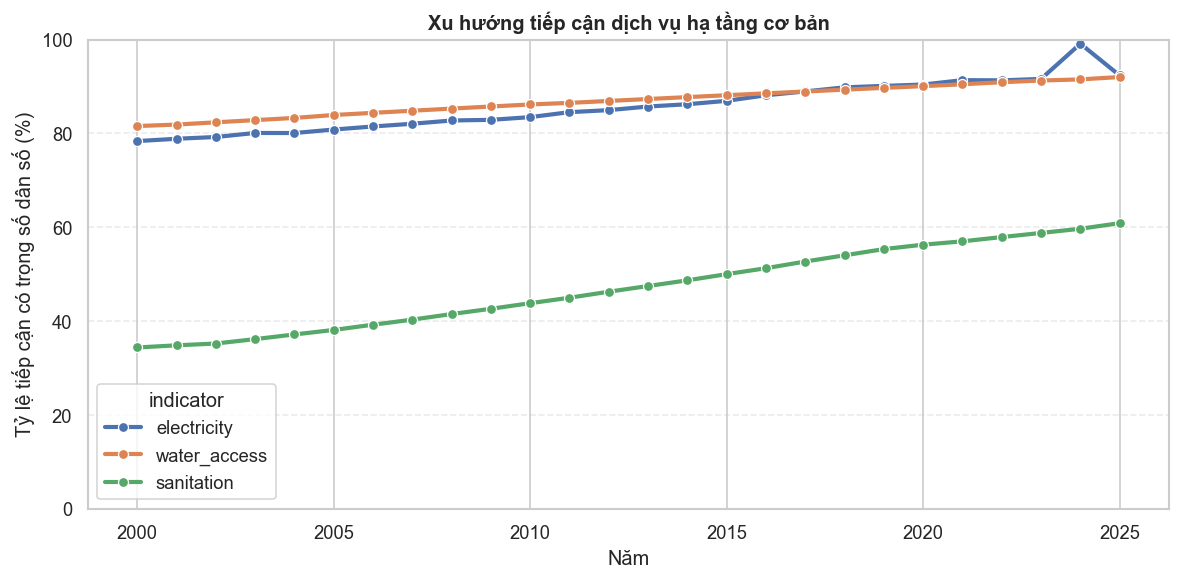

In [14]:
services_trend = []

for year, year_df in df.groupby("year"):
    for col in service_cols:
        services_trend.append({
            "year": year,
            "indicator": col,
            "coverage": weighted_mean(year_df, col),
        })

services_trend_df = pd.DataFrame(services_trend)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=services_trend_df,
    x="year",
    y="coverage",
    hue="indicator",
    marker="o",
    linewidth=2.5,
)
plt.ylim(0, 100)
plt.title("Xu hướng tiếp cận dịch vụ hạ tầng cơ bản", fontweight="bold")
plt.xlabel("Năm")
plt.ylabel("Tỷ lệ tiếp cận có trọng số dân số (%)")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "global_services_trend.png", bbox_inches="tight")
plt.show()


## 7. Tổng kết nhanh

In [15]:
latest_year = df["year"].max()
latest = df[df["year"] == latest_year].copy()

quick_summary = pd.DataFrame({
    "metric": [
        "latest_year",
        "global_weighted_life_expectancy",
        "global_weighted_gdp_per_capita",
        "mean_sanitation",
        "mean_electricity",
        "mean_water_access",
    ],
    "value": [
        latest_year,
        weighted_mean(latest, "life_expectancy"),
        weighted_mean(latest, "gdp_per_capita_reconstructed"),
        weighted_mean(latest, "sanitation"),
        weighted_mean(latest, "electricity"),
        weighted_mean(latest, "water_access"),
    ],
})

quick_summary


,metric,value
0,latest_year,"2,025.0000"
1,global_weighted_life_expectancy,72.9765
2,global_weighted_gdp_per_capita,"13,779.5733"
3,mean_sanitation,60.8443
4,mean_electricity,92.3293
5,mean_water_access,91.9992
